$$\frac{\partial T}{\partial t} - \nu \frac{\partial ^2 T}{\partial x^2} - \nu \frac{\partial ^2 T}{\partial y^2} = -\nu(6x-4)$$


---



* $T(x,y,t) = 0,\ for\ x=0\ and\ x=1$

* $-\nu(x,y)\nabla T(x,y,t) = 0,\ for\ y=0\ and\ y=1$

* $T(x,y,0) = 0,\ (x,y)\in\Omega$

* Solução Analítica: $$T(x) = x^3 -2 x^2 + x$$



---



# Bibliotecas

In [2]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy.sparse import diags
from IPython.display import display, Math, Latex

import scipy as sc
from scipy.sparse.linalg import cg
from scipy.sparse import csr_matrix
from scipy.linalg import toeplitz

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files
from collections import Counter

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, configuration, Eq, solve, Constant
#from sympy import nsimplify, pprint
from devito.logger import warning
from examples.cfd import plot_field, init_hat
#from sympy.abc import a
from os import name

# Problema

In [3]:
nx = 21
ny = nx

nu = 1

x0         = 0
x1         = 1
compx      = x1-x0
y0         = 0
y1         = 1
compy      = y1-y0

dx = 1. / (nx - 1)
dy = 1. / (ny - 1)
sigma = .25
dt = sigma * dx * dy / nu

dx = compx / (nx - 1)
dy = compy / (ny - 1)
sigma = .25
dt = sigma * dx * dy / nu

tstop = 2
nt = round(tstop/dt)

In [4]:
origin = (x0,y0)
extent = (compx,compy)
shape  = (nx,ny)
grid   = Grid(origin=origin,extent=extent,shape=shape)

In [5]:
(x, y)  = grid.dimensions
time    = grid.time_dim
t       = grid.stepping_dim

xf = Function(name ='xf', shape=(nx,), dimensions=(x,))
xf.data[:] = np.linspace(x0, x1, nx)

In [6]:
f = Function(name ='f', shape=(nx,), dimensions = (x,))
f.data[:] = -nu* (6*xf.data[:] - 4)

In [7]:
u = TimeFunction(name='u', grid=grid, space_order=2)
right = f

eq = Eq(u.dt - nu * (u.laplace), right)
stencil = solve(eq, u.forward)
eq_stencil = Eq(u.forward, stencil)

eq_stencil

Eq(u(t + dt, x, y), dt*(f(x) + Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + u(t, x, y)/dt))

In [8]:
eq_stencil.evaluate

Eq(u(t + dt, x, y), dt*(-2.0*u(t, x, y)/h_x**2 + u(t, x - h_x, y)/h_x**2 + u(t, x + h_x, y)/h_x**2 - 2.0*u(t, x, y)/h_y**2 + u(t, x, y - h_y)/h_y**2 + u(t, x, y + h_y)/h_y**2 + f(x) + u(t, x, y)/dt))

In [9]:
# Initial Condition
u.data[0] = 0

# Boundary Conditions
bc = [Eq(u[t+1,0, y], 0.)]  # p = 0 @ x = 0
bc += [Eq(u[t+1,nx-1, y], 0)]  # p = y @ x = 1

bc += [Eq(u[t+1,x, 0], u[t+1,x, 1])]  # dp/dy = 0 @ y = 0
bc += [Eq(u[t+1,x, ny-1], u[t+1,x, ny-2])]  # dp/dy = 0 @ y = 1


op = Operator([eq_stencil] + bc)

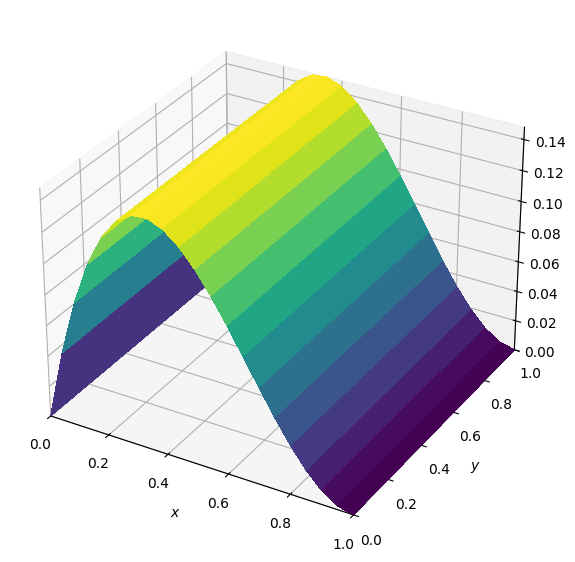

In [10]:
configuration['log-level'] = 'ERROR'

op(time=nt,dt = dt)

plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

## Analítica

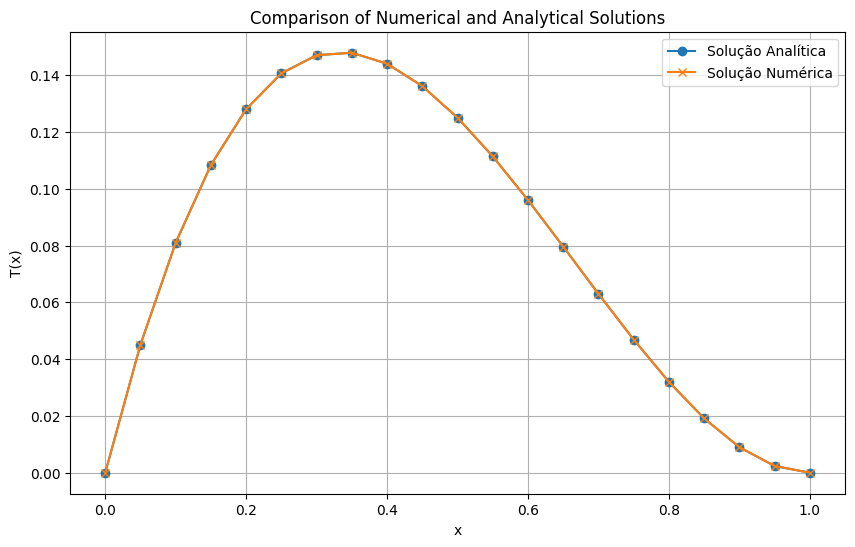

In [11]:
# Solução Analítica
x_analytical = np.linspace(x0, x1, nx)
T_analytical = x_analytical**3 - 2 * x_analytical**2 + x_analytical

# Comparação
plt.figure(figsize=(10, 6))
plt.plot(x_analytical, T_analytical, label='Solução Analítica', marker='o')
plt.plot(xf.data[:], u.data[0, :, ny//2], label='Solução Numérica', marker='x')
plt.xlabel('x')
plt.ylabel('T(x)')
plt.title('Comparison of Numerical and Analytical Solutions')
plt.legend()
plt.grid(True)
plt.show()

# Completo

In [12]:
def run_simulation(nx_values=[21, 41, 81, 161]):
    convergence_results = []
    all_results = {}

    for nx in nx_values:
        print(f"\nRunning simulation for nx = {nx}\n")
        ny = nx
        nu = 1

        x0 = 0
        x1 = 1
        compx = x1 - x0
        y0 = 0
        y1 = 1
        compy = y1 - y0

        dx = compx / (nx - 1)
        dy = compy / (ny - 1)
        sigma = 0.25
        dt = sigma * dx * dy / nu

        tstop = 1
        nt = round(tstop / dt)
        origin = (x0, y0)
        extent = (compx, compy)
        shape = (nx, ny)
        grid = Grid(origin=origin, extent=extent, shape=shape)
        (x, y) = grid.dimensions
        time = grid.time_dim
        t = grid.stepping_dim
        X,Y = np.meshgrid(np.linspace(x0, x1, nx), np.linspace(y0, y1, ny), indexing='ij')


        xf = Function(name='xf', shape=(nx,), dimensions=(x,))
        xf.data[:] = np.linspace(x0, x1, nx)
        f = Function(name='f', shape=(nx,), dimensions=(x,))
        f.data[:] = -nu * (6 * xf.data[:] - 4)
        u = TimeFunction(name='u', grid=grid, space_order=2)

        right = f
        eq = Eq(u.dt - nu * (u.laplace), right)
        stencil = solve(eq, u.forward)
        eq_stencil = Eq(u.forward, stencil)

        u.data[0] = X**3 - 2 * X**2 + X

        # Boundary Conditions
        bc = [Eq(u[t + 1, 0, y], 0.)]
        bc += [Eq(u[t + 1, nx - 1, y], 0)]
        bc += [Eq(u[t + 1, x, 0], u[t + 1, x, 1])]
        bc += [Eq(u[t + 1, x, ny - 1], u[t + 1, x, ny - 2])]

        op = Operator([eq_stencil] + bc)
        configuration['log-level'] = 'ERROR'
        op(time=nt - 1, dt=dt)

        # Plot field
        plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

        # Analytical Solution
        x_analytical = np.linspace(x0, x1, nx)
        T_analytical = X**3 - 2 * X**2 + X

        # Comparison Plot
        plt.figure(figsize=(10, 6))
        plt.plot(x_analytical, T_analytical[:, ny//2], label='Solução Analítica', marker='o')
        plt.plot(xf.data[:], u.data[0, :, ny//2], label='Solução Numérica', marker='x')
        plt.xlabel('x')
        plt.ylabel('T(t,x,y)')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Relative Error Plot
        relative_error = np.sqrt(np.sum((T_analytical - u.data)**2 )) / np.sqrt(np.sum((T_analytical)**2 ))

        # Store results for convergence analysis
        all_results[nx] = {
            'x': xf.data[:],
            'numerical': u.data[0, :, ny//2],
            'analytical': T_analytical,
            'rel_error': relative_error,
            'h': dx,
            'dt': dt
        }

    # Calculate convergence rates
    nx_sorted = sorted(all_results.keys())
    for i, nx in enumerate(nx_sorted):
        if i == 0:
            q_h = np.nan
            q_dt = np.nan
        else:
            prev_nx = nx_sorted[i-1]
            E1 = all_results[prev_nx]['rel_error']
            E2 = all_results[nx]['rel_error']
            h1 = all_results[prev_nx]['h']
            h2 = all_results[nx]['h']
            dt1 = all_results[prev_nx]['dt']
            dt2 = all_results[nx]['dt']

            q_h = np.log(E1/E2) / np.log(h1/h2)
            q_dt = np.log(E1/E2) / np.log(dt1/dt2)

        convergence_results.append({
            'N (nx)': nx,
            'h': all_results[nx]['h'],
            'dt_cfl': all_results[nx]['dt'],
            'Erro (relativo)': all_results[nx]['rel_error'],
            'q_h': q_h,
            'q_dt_cfl': q_dt
        })

    # Create and display convergence table
    df_convergence = pd.DataFrame(convergence_results)
    print("\nConvergence Analysis Table:")
    print(df_convergence.to_string(float_format="%.4e"))

    return all_results, df_convergence


Running simulation for nx = 11



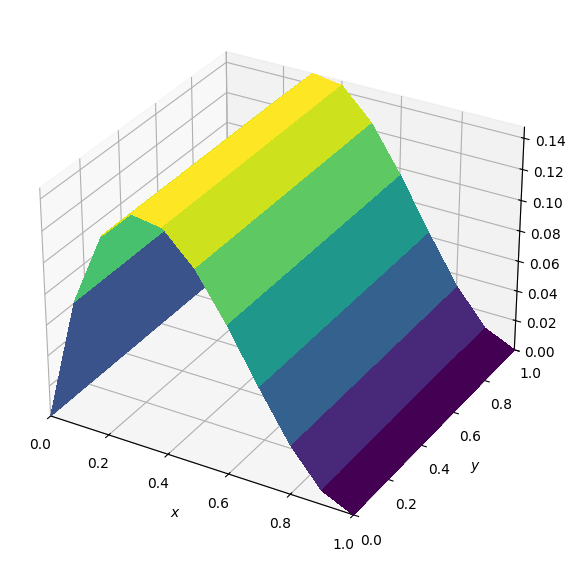

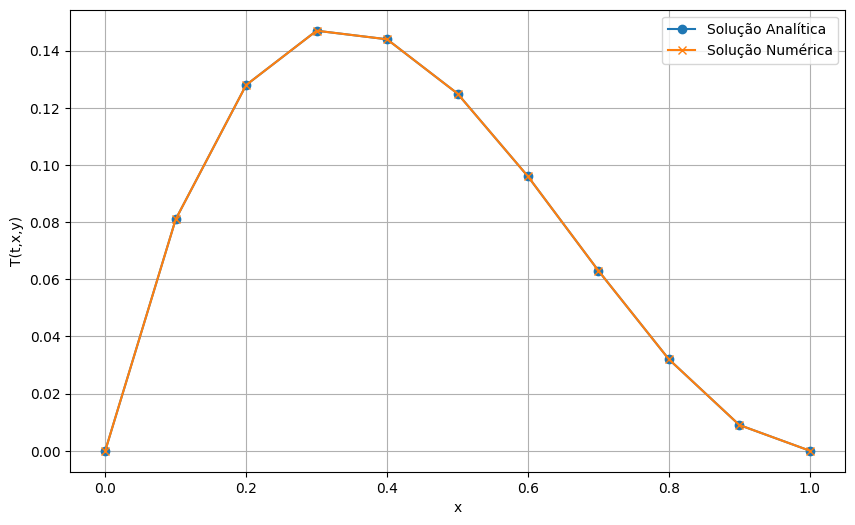


Running simulation for nx = 21



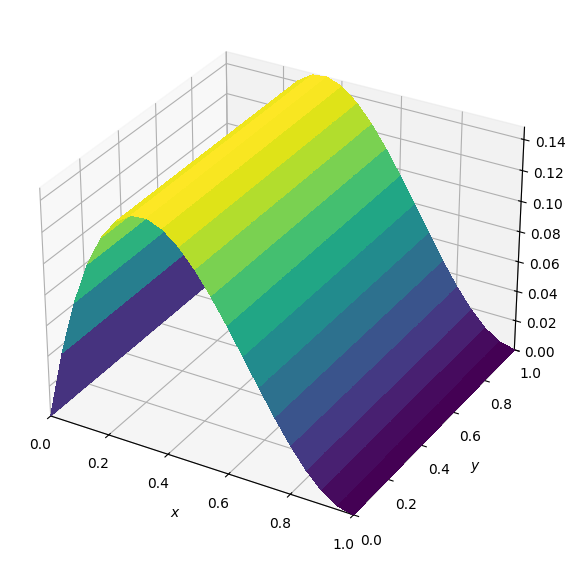

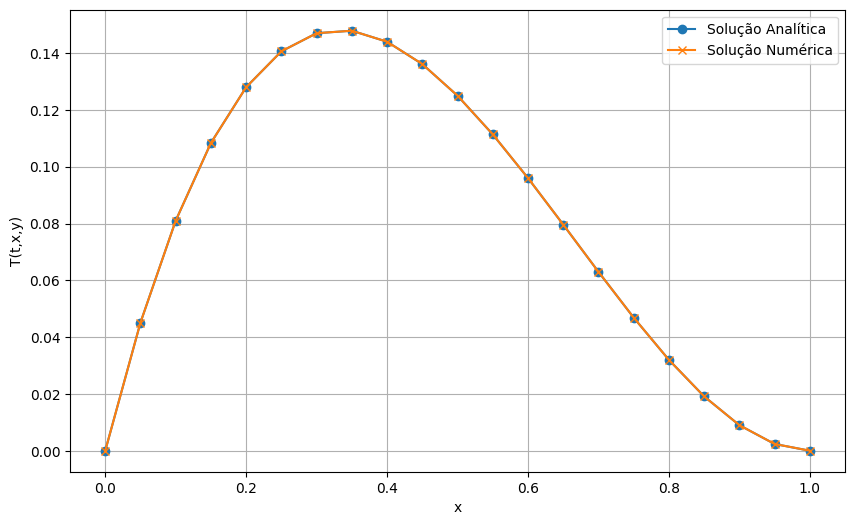


Running simulation for nx = 41



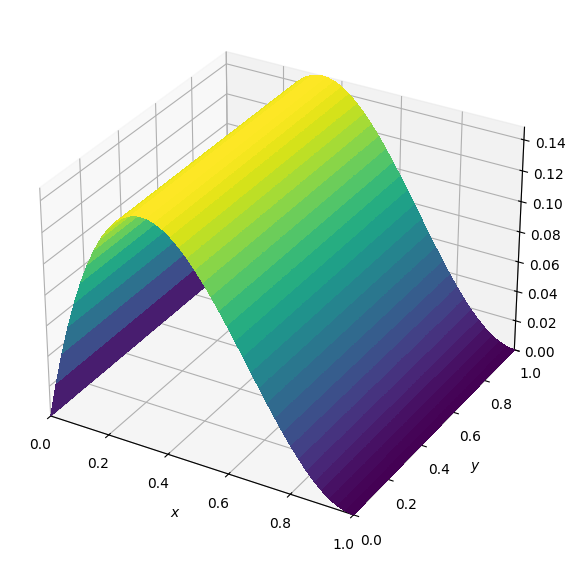

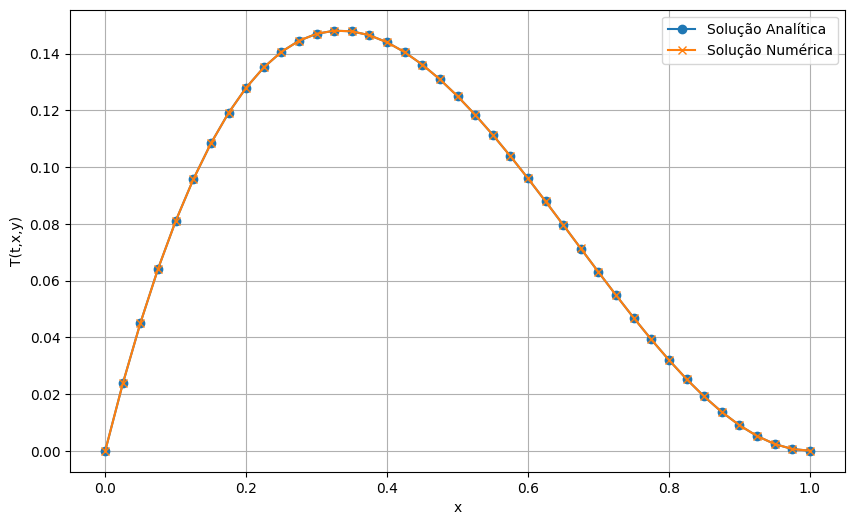


Running simulation for nx = 81



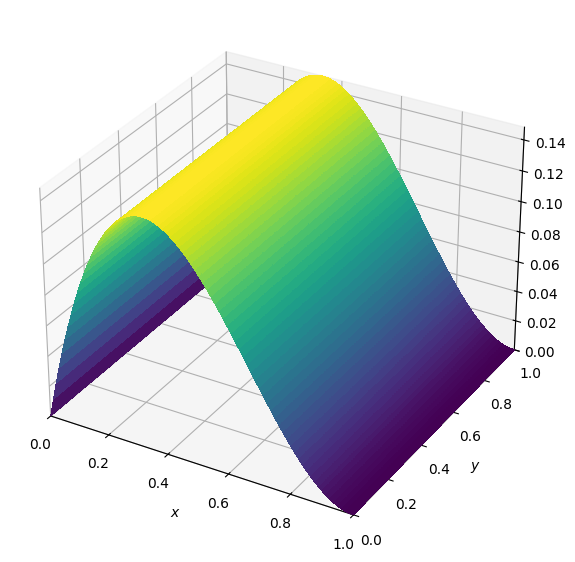

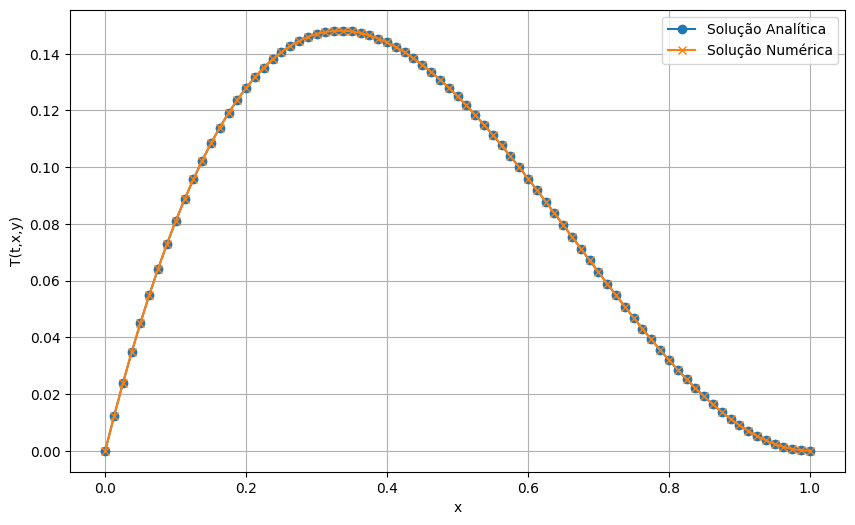


Convergence Analysis Table:
   N (nx)          h     dt_cfl         Erro (relativo)                   q_h              q_dt_cfl
0      11 1.0000e-01 2.5000e-03  5.8345672503637604e-08                   NaN                   NaN
1      21 5.0000e-02 6.2500e-04  5.5642932109796886e-08   0.06842721042234966   0.03421360521117483
2      41 2.5000e-02 1.5625e-04   7.181445242107185e-08  -0.36807576603247877  -0.18403788301623938
3      81 1.2500e-02 3.9063e-05   1.070976626556517e-07   -0.5765808784636808   -0.2882904392318404


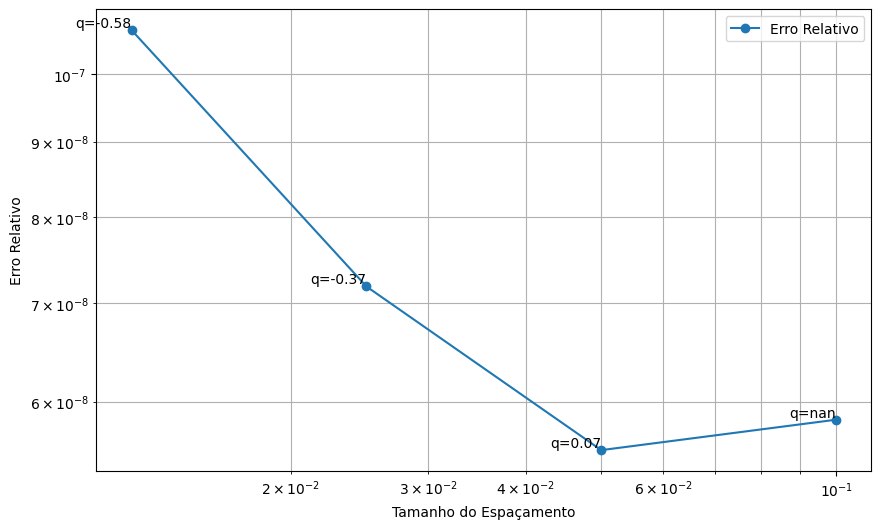

In [13]:
# Run simulations
all_results, df_convergence = run_simulation(nx_values=[11, 21, 41, 81])

# Additional convergence plot
plt.figure(figsize=(10, 6))
plt.loglog(df_convergence['h'], df_convergence['Erro (relativo)'], 'o-', label='Erro Relativo')
for i, row in df_convergence.iterrows():
    plt.text(row['h'], row['Erro (relativo)'], f"q={row['q_h']:.2f}", ha='right', va='bottom')
plt.xlabel('Tamanho do Espaçamento')
plt.ylabel('Erro Relativo')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()